In [29]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score,recall_score, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import itertools

%matplotlib inline

### 1. EDA (Exploratory Data Analysis)

In [ ]:
# Read in data
df = pd.read_csv('/Users/AnhHuynh/AIT736-Team3/data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Check for total number of rows and columns
df.shape

(7043, 21)

In [5]:
# Check null values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
# Check data types of each columns
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [7]:
# Descriptive statistics
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [8]:
# Count of unique values for all string columns
print(df.select_dtypes(include=['object']).nunique())

customerID          7043
gender                 2
Partner                2
Dependents             2
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
TotalCharges        6531
Churn                  2
dtype: int64


/var/folders/4p/strpkrbd1y782g01xksphyv40000gn/T/ipykernel_66062/2451002218.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include=['object']).nunique())


In [9]:
string_cols = df.select_dtypes(include=['object']).columns

for col in string_cols:
	unique_values = print(f"Unique value in {col}: {df[col].unique()}")

Unique value in customerID: <StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str
Unique value in gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Unique value in Partner: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Unique value in Dependents: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Unique value in PhoneService: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Unique value in MultipleLines: <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
Unique value in InternetService: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
Unique value in OnlineSecurity: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
Unique value in OnlineBackup

/var/folders/4p/strpkrbd1y782g01xksphyv40000gn/T/ipykernel_66062/324812339.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = df.select_dtypes(include=['object']).columns


### Data Preparation

* For string columns that have only 2 values, we can use binary encoding (replace with 0 and 1)
* For string columns that have 3 values or more, we use one hot encoding

#### Binary Encoding

In [10]:
binary_cols = [
  'gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn' 
]

# Map Yes/No and Male/Female to 1/0
df[binary_cols] = df[binary_cols].replace({
	'Yes': 1, 'No': 0,
	'Male': 1, 'Female': 0
})

df[binary_cols] = df[binary_cols].apply(pd.to_numeric,errors='coerce').astype('int64')

#### One-Hot Encoding

In [11]:
# Categorical columns that have more than 2 unique values

multi_cat_columns = [
	'MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract', 'PaymentMethod'	
]

# One-hot encode
df = pd.get_dummies(df, columns=multi_cat_columns,drop_first=True)

In [12]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,...,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.5,...,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,...,False,False,False,False,False,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,...,True,False,False,False,False,True,False,False,False,False
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,...,False,False,False,False,False,False,False,False,True,False
5,9305-CDSKC,0,0,0,0,8,1,1,99.65,820.5,...,False,False,True,False,True,False,False,False,True,False
6,1452-KIOVK,1,0,0,1,22,1,1,89.10,1949.4,...,False,False,True,False,False,False,False,True,False,False
7,6713-OKOMC,0,0,0,0,10,0,0,29.75,301.9,...,False,False,False,False,False,False,False,False,False,True
8,7892-POOKP,0,0,1,0,28,1,1,104.80,3046.05,...,True,False,True,False,True,False,False,False,True,False
9,6388-TABGU,1,0,0,1,62,1,0,56.15,3487.95,...,False,False,False,False,False,True,False,False,False,False


#### Cleaning

In [13]:
# Ensure Total Charages column in numeric type
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [14]:
# Drop unused customer_id column
df=df.drop('customerID',axis=1)

In [15]:
# Transfrom boolean columns into 1/0
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype('int64')

In [16]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  MultipleLines_Y

* The TotalCharge columns miss 11 values after being casted to float data type
* Since 11 values account for 0.2% of the dataset, we drop those rows

In [18]:
df = df.dropna(subset=['TotalCharges'])
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  MultipleLines_No phone service         7032 non-null   int64  
 11  MultipleLines_Yes   

#### Data visualization

Text(0.5, 1.0, 'Correlation of features with Churn')

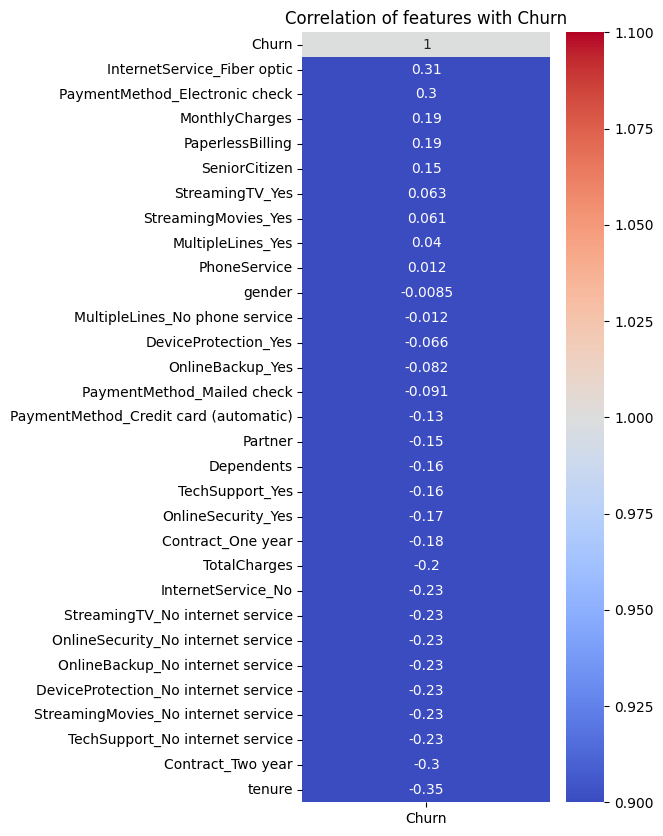

In [19]:
# Create correlation matrix
corr_max = df.corr(numeric_only=True)

# Correlation between independent and depedent variables
churn_corr = corr_max[['Churn']].sort_values(by='Churn', ascending=False)

# Plot heat map
plt.figure(figsize=(4,10))
sns.heatmap(churn_corr,annot=True,cmap='coolwarm',vmin=1,vmax=1)
plt.title("Correlation of features with Churn")

#### Observations
- Positive (higher the value = higher the churn likelihood)
	* Customer who use fiber optic internet is more likely to churn.
	* Customers who pay electronically also churn more compared to those who mail checks or use credit card. 

- Negative (higher the value = lower the churn probability)
	* Customers who stay longer are less likely to churn.
	* Customers who have 2-year contract are also less likely to churn compared to those who contracted for 1 year only. 


#### Multicollinearity

In [20]:
X = df.select_dtypes(include=[np.number])

vif_data=pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_data.sort_values("VIF", ascending=False)


/Users/AnhHuynh/AIT736-Team3/.venv/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
13,InternetService_No,inf
14,OnlineSecurity_No internet service,inf
24,StreamingMovies_No internet service,inf
20,TechSupport_No internet service,inf
22,StreamingTV_No internet service,inf
18,DeviceProtection_No internet service,inf
16,OnlineBackup_No internet service,inf
5,PhoneService,1774.603920
7,MonthlyCharges,866.100958
12,InternetService_Fiber optic,148.578927


#### Observations

* VIF - Variance Inflation Vector quantify the extent of correlation between a predictor to other predictors in a model. In other words, it measures multicollinearity problem.

* VIF ranges from 1 to infinite, which 1 indicates no collinearity, and infinitive indicates perfect collinearity. In case of VIF > 5 to inf, predictor(s) need to be removed.

#### Conclusion

* Since the dataset has multicollinearity problem, we will use tree-based models istead of regression model.

* The 2 Machine Learning models used are XGBoost and Random Forest

### 2. Machine Learning 

In [21]:
df['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

#### Observation
* The data is moderately imbalanced with churners represent approximately 27% of the data. 

* This may cause:
	* False Negative: We predict a customer will not churn but they actually leave
	* False Positive: We predict a customer will churn but they stay

* 🎯 Goal:
	* We want to minimize False Negatives. 
	

In [22]:
# Define X, y and split data

X = df.drop(columns=['Churn'])
y = df['Churn']

# Train-test-split
X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.2, random_state=42, stratify=y
)

#### 2.1. Random Forest Classifier

In [23]:
"""
Adjust the threshold (cutoff value), which used to convert probability to label, to 0.3
"""
rf = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced', #balance imbalanced data
    random_state=42,
    n_jobs=1
)

rf.fit(X_train,y_train)

threshold = 0.3
proba = rf.predict_proba(X_test)[:,1]
y_pred = (proba >= threshold).astype('int64')

print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.890     0.753     0.816      1033
           1      0.522     0.743     0.613       374

    accuracy                          0.751      1407
   macro avg      0.706     0.748     0.714      1407
weighted avg      0.792     0.751     0.762      1407



#### 2.2. XGBoost Classifier

In [24]:
"""
We use scale_pos_weight hyperparameter to balance the influence of churn and non-churn class
"""
scale_pos_weight = (y_train==0).sum()/(y_train==1).sum()

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

xgb.fit(X_train,y_train)

threshold = 0.3

proba_xgb = xgb.predict_proba(X_test)[:,1]
y_pred_xgb=(proba_xgb>=threshold).astype('int64')

print(classification_report(y_test,y_pred_xgb,digits=3))

              precision    recall  f1-score   support

           0      0.901     0.676     0.772      1033
           1      0.470     0.794     0.590       374

    accuracy                          0.707      1407
   macro avg      0.685     0.735     0.681      1407
weighted avg      0.786     0.707     0.724      1407



### Parameters explanation

* 🌳 n_estimators: Number of boosting rounds (number of trees built)
    * With more trees, the model can learn complex pattern
    * Too many trees can cause overfitting if learning rate is high

* 📈 learning_rate: control how much each tree contributes to the final prediction
    * Smaller learning rate means the model learns slower but more stable

* 🧊 max_depth: maximum depth of each tree
    * 3: simple
    * 6: default
    * 10+: complex with risk of overfitting

* 🫟 subsample: percentage of rows used to build each tree
    * Help reduce overfitting by adding randomness

* 🧩 colsample_bytree: percentage of features used per tree
    * Also reduce overfitting and improve generalization


### Conclusion

* Since our business goal is not to miss churners, we want to use the model that has higher receall value (lower False Negatives)
* In our case, XGBoost with same threshold return higher recall (lower churner rate)

### Tuning

##### Hyperparamter Tuning

In [25]:
param_grid = {
    "n_estimators": [200,500],
    "learning_rate": [0.01, 0.05],
    "max_depth": [3, 5, 6],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

#### Testing on different CVs and thresholds

In [32]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
thresholds = [0.1, 0.25, 0.3, 0.35, 0.4, 0.5]

results = []

for v in itertools.product(*values):
    params = dict(zip(keys, v))

    # store fold metrics per threshold
    fold_scores = {t: {"recall": [], "f1": []} for t in thresholds}

    for train_idx, val_idx in skf.split(X, y):

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = XGBClassifier(
            **params,
            random_state=42,
            n_jobs=1,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss"
        )

        model.fit(X_train, y_train)
        probs = model.predict_proba(X_val)[:, 1]

        # apply thresholds WITHOUT retraining
        for t in thresholds:
            preds = (probs >= t).astype(int)

            fold_scores[t]["recall"].append(recall_score(y_val, preds))
            fold_scores[t]["f1"].append(f1_score(y_val, preds))

    # average across folds
    for t in thresholds:
        results.append({
            "params": params,
            "threshold": t,
            "recall": np.mean(fold_scores[t]["recall"]),
            "f1": np.mean(fold_scores[t]["f1"])
        })

In [33]:
df_results = pd.DataFrame(results)

best_by_recall = df_results.sort_values("recall", ascending=False).head(1)
best_by_f1 = df_results.sort_values("f1", ascending=False).head(1)

print(best_by_recall)
print(best_by_f1)

                                              params  threshold   recall  \
0  {'n_estimators': 200, 'learning_rate': 0.01, '...        0.1  0.99572   

         f1  
0  0.440291  
                                                params  threshold    recall  \
173  {'n_estimators': 500, 'learning_rate': 0.01, '...        0.5  0.787061   

           f1  
173  0.633958  


#### Observation

* At row 0, the recall score of 0.99572 is almost perfect, but F1 score is very low - only 0.44.
* What it means:
    * At threshold 0.1, the model predicts almost everyone as churner.
    * F1 score - the balance between false positive and false negative becomes terrible.

* At row 173:
    * Fewer false positive
    * Recall decreases slightly


* We want to maximize our ability to identify churners while minimizing the misclassification of customers who stay as customers who leave.

In [36]:
df_results[(df_results["recall"] >= 0.80)].sort_values("f1", ascending=False).head(10)

,params,threshold,recall,f1
149,"{'n_estimators': 500, 'learning_rate': 0.01, '...",0.5,0.815952,0.633736
95,"{'n_estimators': 200, 'learning_rate': 0.05, '...",0.5,0.803649,0.632097
155,"{'n_estimators': 500, 'learning_rate': 0.01, '...",0.5,0.814345,0.630927
89,"{'n_estimators': 200, 'learning_rate': 0.05, '...",0.5,0.803110,0.630567
77,"{'n_estimators': 200, 'learning_rate': 0.05, '...",0.5,0.802043,0.629848
41,"{'n_estimators': 200, 'learning_rate': 0.01, '...",0.5,0.803107,0.629353
35,"{'n_estimators': 200, 'learning_rate': 0.01, '...",0.5,0.800433,0.628717
167,"{'n_estimators': 500, 'learning_rate': 0.01, '...",0.5,0.810603,0.628684
161,"{'n_estimators': 500, 'learning_rate': 0.01, '...",0.5,0.810602,0.627869
47,"{'n_estimators': 200, 'learning_rate': 0.01, '...",0.5,0.803108,0.626241


#### Observaation

* At row 149:
    * Recall is highest among top 10 results.
    * F1 score is also the highest.

* This result tell us that the business correctly identifies 81.6% of actual churners.

#### Model selection

In [38]:
# Extract the parameters of model selected
best_params = df_results.loc[149, "params"]
best_threshold = df_results.loc[149, "threshold"]

print(best_params)
print(best_threshold)

{'n_estimators': 500, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.8}
0.5


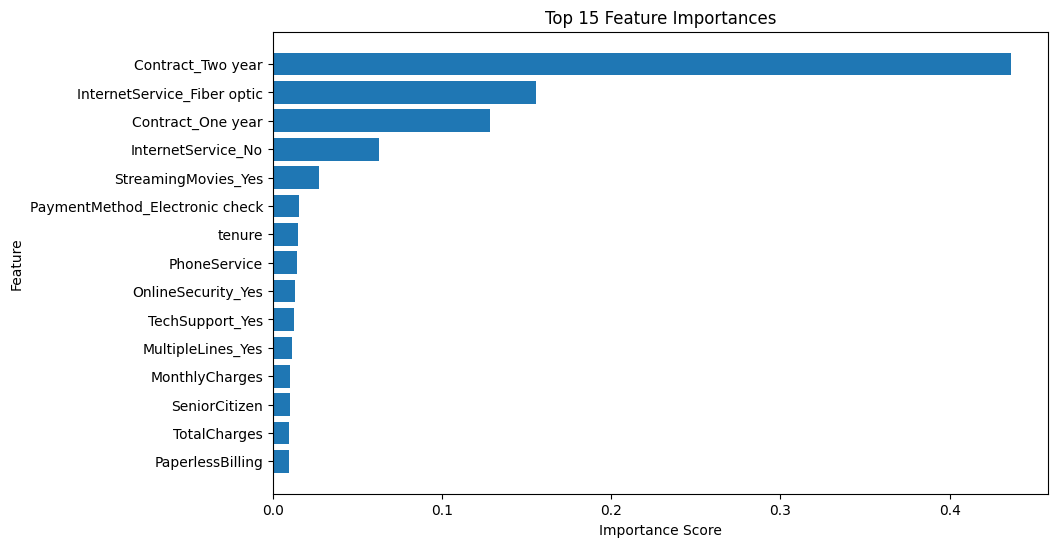

In [34]:
importances = model.feature_importances_
feat_names = X.columns

fi = pd.DataFrame({"Feature": feat_names, "Importance": importances})
fi = fi.sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(10,6))
plt.barh(fi["Feature"], fi["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

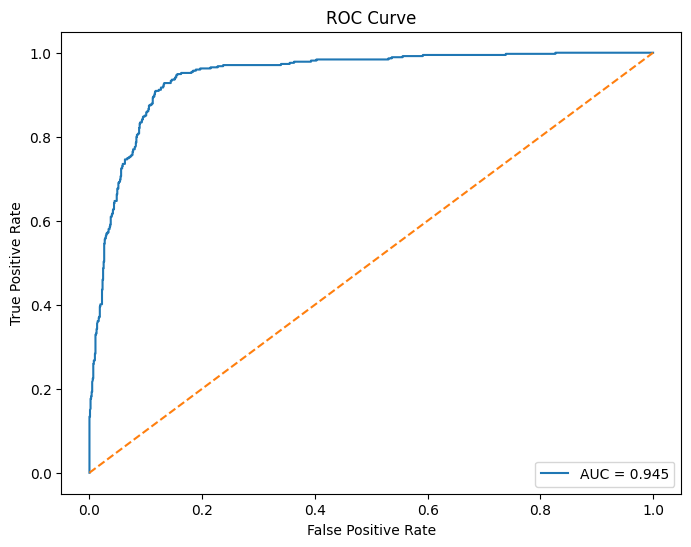

In [35]:
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

* The ROC Curve plot tells us that our model correctly ranks a churner over a non-churner 94.5% of time, which is very good. 